---
title: "Demo van GWDI"
---


## Afleiden van statistiek van de afgelopen 30 jaar


In [45]:
import os  # noqa: F401
from pathlib import Path

import pandas as pd
import pastas as ps

from toolbox_continu_inzicht.base.adapters.input.pastas_models import (
    input_pastas_models,
)
from toolbox_continu_inzicht.gwdi.processing.gwdi_reference_stats import (
    compute_df_stats_minima,
    prepare_reference_climate,
)

In [46]:
# Gebruik lokale voorbeelddata in deze notebook-map.
data_dir = Path.cwd() / "data_sets"

path_precipitation = data_dir / "reference_precipitation_regions.csv"
path_evaporation = data_dir / "reference_evaporation.csv"
path_info = data_dir / "gwdi_pastas_mapping_all.csv"
path_models = data_dir / "pastas_models"

output_path = data_dir / "df_stats_minima.csv"

In [47]:
# 1) Laad ruwe klimaatinput als dataframes
df_precipitation_regions = pd.read_csv(
    path_precipitation,
    parse_dates=["time"],
    index_col="time",
)
df_evaporation = pd.read_csv(
    path_evaporation,
    parse_dates=["time"],
    index_col="time",
)

# 2) Maak klimaatreeksen in meter
prec100, evap100 = prepare_reference_climate(
    df_precipitation_regions=df_precipitation_regions,
    df_evaporation=df_evaporation,
    precipitation_column="prec_R-R",
    evaporation_column="makkink",
)

# 3) Laad locatie-info en Pastas-modellen
info_locaties = pd.read_csv(path_info)
info_locaties.index = info_locaties["location"].astype(str)
info_locaties["position"] = info_locaties["position"].astype(str)

dict_models_raw = input_pastas_models({"abs_path": path_models})
dict_models_by_location = {
    loc: dict_models_raw[f"{loc}_{info_locaties.loc[loc, 'position']}_tarso"]
    for loc in info_locaties.index
}

# 4) Bereken df_stats_minima
df_stats_minima = compute_df_stats_minima(
    info_locaties=info_locaties,
    dict_models=dict_models_by_location,
    prec100=prec100,
    evap100=evap100,
    ps_module=ps,
)

# Opslaan
df_stats_minima.to_csv(output_path)

df_stats_minima

location,100_1,101_1,103_1,111_2,148_1,149_1,150_1,153_1,53_1,54_1,...,Geer- en Blankaardpolder_4,Groeneveldse Molen_3,Hennipslootkade_4,Meetraai20_a_2,Meetraai25_2,Molenlaan_3,MT polder_4,Noordring_3,Oldelamerbrug_3,Wymerts_3
1,-3.903079,-4.580507,-3.926634,-3.506799,-1.670631,-1.97617,-1.516825,-2.02149,-3.267204,-3.386009,...,-3.217385,-1.894646,-4.093711,-4.129153,-2.990221,-1.726915,-5.495956,-4.346055,-1.502597,-1.426549
3,-3.947423,-4.610264,-4.278589,-3.647989,-1.705498,-2.063745,-1.554465,-2.157436,-3.376342,-3.460352,...,-3.269033,-2.053603,-4.231915,-4.168353,-3.066775,-1.874489,-6.076818,-4.386962,-1.618034,-1.491527
10,-4.024361,-4.657094,-4.381818,-3.712129,-1.761031,-2.202246,-1.602403,-2.233601,-3.422585,-3.559419,...,-3.332955,-2.135937,-4.408357,-4.223194,-3.163386,-1.947201,-6.228813,-4.451385,-1.763038,-1.567236
30,-4.106235,-4.705312,-4.443347,-3.756081,-1.818441,-2.34509,-1.648383,-2.289431,-3.453573,-3.655886,...,-3.393685,-2.194782,-4.577731,-4.277473,-3.25577,-1.998341,-6.316189,-4.517735,-1.901484,-1.637738
100,-4.203744,-4.761712,-4.497416,-3.797539,-1.885742,-2.512329,-1.700141,-2.343956,-3.482472,-3.765362,...,-3.461696,-2.251506,-4.768471,-4.339617,-3.359591,-2.047231,-6.391592,-4.595357,-2.056941,-1.715846
300,-4.298047,-4.815576,-4.539709,-3.83161,-1.950115,-2.672147,-1.748261,-2.389863,-3.506032,-3.867726,...,-3.524702,-2.298831,-4.94586,-4.398082,-3.456006,-2.087786,-6.449832,-4.669495,-2.201224,-1.787662
1000,-4.406099,-4.876702,-4.580925,-3.866082,-2.023253,-2.853597,-1.801758,-2.437175,-3.529725,-3.982023,...,-3.594554,-2.347267,-5.143112,-4.46367,-3.563097,-2.12911,-6.506046,-4.753634,-2.361412,-1.866825


## Operationele script


In [48]:
config_path = data_dir / "gwdi_demo.yaml"

In [49]:
import os  # noqa: F401, F811
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from toolbox_continu_inzicht import Config, DataAdapter
from toolbox_continu_inzicht.gwdi import (
    GwdiInference,
    GwdiKnmiRetrieval,  # noqa: F401
    GwdiWiwbRetrieval,  # noqa: F401
)

De configuratie ziet er als volgt uit:

```yaml
GlobalVariables:
    rootdir: "data_sets"
    calc_time: "2025-06-11 00:00:00"

DataAdapter:
    gwdi_input_precipitation_dynamic:
        type: python
    gwdi_input_evaporation_dynamic:
        type: python

    gwdi_input_climate_sampling_locations:
        type: csv
        file: "gwdi_beemster_loc.csv"

    gwdi_input_pastas_mapping:
        type: csv
        file: "gwdi_pastas_mapping_all.csv"
        dtype:
            location: object
            position: object
    gwdi_input_pastas_models:
        type: pastas_models
        path: "pastas_models"
    gwdi_input_stats_minima:
        type: csv
        file: "df_stats_minima.csv"
        index_col: 0
    gwdi_output:
        type: csv
        file: "gwdi_ouput.csv"
```


In [50]:
config = Config(config_path=config_path)
config.lees_config()

## Historische Klimaatreeks

Om de pastas modellen correct te runnen moet een langer periode worden mee gegeven.

In dit voorbeeld runnen vanaf 2020 tot 2025. 
Deze data is eerder opgehaal via WIWB en opgeslagen, later wordt deze live kopeling laten zien.  

In [51]:
path_reference_precipitation_dynamic = (
    data_dir / "reference_da_merged_precipitation.csv"
)
path_reference_evaporation_dynamic = data_dir / "reference_da_merged_evaporation.csv"
path_reference_da_merged_metadata = data_dir / "reference_da_merged_metadata.csv"

reference_da_merged_metadata = pd.read_csv(path_reference_da_merged_metadata)
display(reference_da_merged_metadata)

,source,target_fid,target_name,target_x,target_y,selected_fid,selected_x,selected_y,distance_m,metric_crs,time_start,time_end,n_days
0,gwdi\datamerger\da_merged.nc,300268,gwdi_beemster,4.996749,52.575284,302233,4.999799,52.576099,225.741082,EPSG:32631,2020-01-02 00:00:00,2025-06-11 00:00:00,1988


In [52]:
# Gebruik dezelfde YAML-configuratie als in het statische voorbeeld.
data_adapter_dynamic = DataAdapter(config=config)

wiwb_out = pd.read_csv(path_reference_precipitation_dynamic, parse_dates=["time"])
knmi_out = pd.read_csv(path_reference_evaporation_dynamic, parse_dates=["time"])

In [53]:
wiwb_grid = wiwb_out[["time", "fid"]].drop_duplicates()
knmi_grid = knmi_out[["time", "fid"]].drop_duplicates()
common_grid = wiwb_grid.merge(knmi_grid, on=["time", "fid"], how="inner")

if len(common_grid) == 0:
    raise UserWarning(
        "Geen overlappende (`time`, `fid`)-grid tussen neerslag en verdamping. "
        "Controleer de invoerreeksen."
    )

df_precip_dynamic = wiwb_out.merge(common_grid, on=["time", "fid"], how="inner")
df_evap_dynamic = knmi_out.merge(common_grid, on=["time", "fid"], how="inner")
df_precip_dynamic = df_precip_dynamic.sort_values(["time", "fid"]).reset_index(
    drop=True
)
df_evap_dynamic = df_evap_dynamic.sort_values(["time", "fid"]).reset_index(drop=True)

print("Gezamenlijk grid:")
display(df_precip_dynamic.merge(df_evap_dynamic, on=["time", "fid"]))

Gezamenlijk grid:


,time,fid,P,evaporation
0,2020-01-02,302233,0.000000,0.109985
1,2020-01-03,302233,0.000000,0.100000
2,2020-01-04,302233,8.509998,0.100000
3,2020-01-05,302233,0.000000,0.120000
4,2020-01-06,302233,0.000000,0.100000
...,...,...,...,...
1983,2025-06-07,302233,1.079971,2.130381
1984,2025-06-08,302233,21.969955,2.500621
1985,2025-06-09,302233,17.110046,3.775830
1986,2025-06-10,302233,0.149979,2.097608


Tenslotte voeren we `GwdiInference` uit met deze dynamische invoer.


In [54]:
data_adapter_dynamic.set_dataframe_adapter(
    "gwdi_input_precipitation_dynamic",
    df_precip_dynamic,
)
data_adapter_dynamic.set_dataframe_adapter(
    "gwdi_input_evaporation_dynamic",
    df_evap_dynamic,
)

module_dynamic = GwdiInference(data_adapter=data_adapter_dynamic)
module_dynamic.run(
    input=[
        "gwdi_input_precipitation_dynamic",
        "gwdi_input_evaporation_dynamic",
        "gwdi_input_pastas_mapping",
        "gwdi_input_pastas_models",
        "gwdi_input_stats_minima",
    ],
    output="gwdi_output",
)

df_gwdi_dynamic = module_dynamic.df_out.copy()

2026-04-30 11:01:49 WARNING - base: The solver object is stored in the model.solver attribute since Pastas 1.3. Please update your pas-file to the new format by loading and saving the file with Pastas 1.3.
2026-04-30 11:01:49 WARNING - base: The solver object is stored in the model.solver attribute since Pastas 1.3. Please update your pas-file to the new format by loading and saving the file with Pastas 1.3.
2026-04-30 11:01:50 WARNING - base: The solver object is stored in the model.solver attribute since Pastas 1.3. Please update your pas-file to the new format by loading and saving the file with Pastas 1.3.
2026-04-30 11:01:50 WARNING - base: The solver object is stored in the model.solver attribute since Pastas 1.3. Please update your pas-file to the new format by loading and saving the file with Pastas 1.3.
2026-04-30 11:01:50 WARNING - base: The solver object is stored in the model.solver attribute since Pastas 1.3. Please update your pas-file to the new format by loading and sav

In [55]:
module_dynamic.data_adapter.set_global_variable("logging", {"level": "CRITICAL"})
module_dynamic.data_adapter.init_logging(re_initialize=True)
module_dynamic._sync_pastas_logger(module_dynamic.data_adapter.logger)
df_gwdi_input_pastas_models = module_dynamic.data_adapter.input(
    "gwdi_input_pastas_models"
)
info_locaties_plot = module_dynamic.data_adapter.input("gwdi_input_pastas_mapping")
peilbuis_index_mapping = dict(
    zip(
        info_locaties_plot["location"],
        range(len(info_locaties_plot)),
    )
)

index_west = peilbuis_index_mapping["Beemster West D_BITA_F-430"]
index_zuid_a = peilbuis_index_mapping["Beemster Zuid A_KR_F-861"]
index_zuid_b = peilbuis_index_mapping["Beemster Zuid B_BITA_F-407"]

#### Plotten van de resultaten

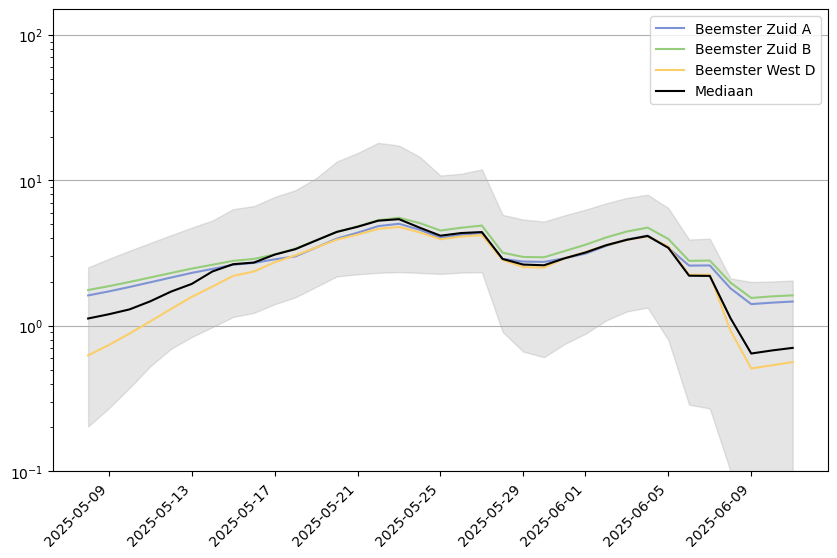

In [56]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 6))
df_gwdi_dynamic["datetime"] = pd.to_datetime(
    df_gwdi_dynamic["datetime"], unit="ms", utc=True
)
df_gwdi_agg = df_gwdi_dynamic.groupby("datetime")["value"].agg(["min", "median", "max"])
ax.fill_between(
    df_gwdi_agg.index,
    df_gwdi_agg["min"],
    df_gwdi_agg["max"],
    alpha=0.2,
    color="grey",
)

df_zuid_a = df_gwdi_dynamic.query("peilbuisid==@index_zuid_a")
ax.plot(
    df_zuid_a["datetime"], df_zuid_a["value"], color="#7d93d3", label="Beemster Zuid A"
)

df_zuid_b = df_gwdi_dynamic.query("peilbuisid==@index_zuid_b")
ax.plot(
    df_zuid_b["datetime"], df_zuid_b["value"], color="#95cd7a", label="Beemster Zuid B"
)

df_west = df_gwdi_dynamic.query("peilbuisid==@index_west")
ax.plot(df_west["datetime"], df_west["value"], color="#fbce69", label="Beemster West D")

ax.plot(df_gwdi_agg.index, df_gwdi_agg["median"], color="k", label="Mediaan")

ax.set_yscale("log")
ax.grid(True, axis="y")
ax.set_ylim([0.1, 150])
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha="right")
ax.legend()

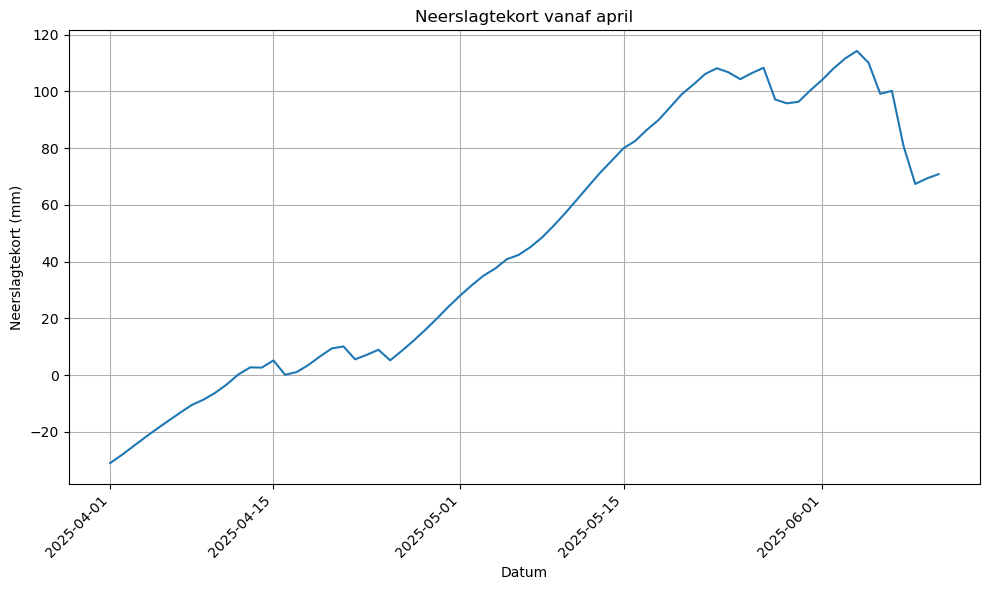

In [57]:
neeslag_tekort = knmi_out["evaporation"] - wiwb_out["P"]
wiwb_out["p-e"] = neeslag_tekort
wiwb = wiwb_out[wiwb_out["time"] >= "2020-04-01"].copy()
wiwb["neerslag_tekort"] = wiwb.groupby(wiwb["time"].dt.year)["p-e"].cumsum()
wiwb[["time", "fid", "P", "neerslag_tekort"]]
wiwb_2025 = wiwb[wiwb["time"] >= "2025-04-01"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wiwb_2025["time"], wiwb_2025["neerslag_tekort"])
ax.set_xlabel("Datum")
ax.set_ylabel("Neerslagtekort (mm)")
ax.set_title("Neerslagtekort vanaf april")
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True)
plt.tight_layout()
plt.show()

# Klimaatreeks via WIWB + KNMI

In dit tweede voorbeeld halen we neerslag en verdamping dynamisch op voor dezelfde GWDI-run:

- `GwdiWiwbRetrieval` levert neerslag (`P`) op.
- `GwdiKnmiRetrieval` levert verdamping (`evaporation`) op.

In `gwdi_simple_calculation.yaml` gebruiken beide retrievals dezelfde resample-configuratie (`resample_frequency`, `resample_period_start`, `resample_period_end`) zodat de tijdstappen op elkaar aansluiten.
Daarna voeren we `GwdiInference` uit met deze dynamische invoer.

De configuratie ziet er als volgt uit:

```yaml
GlobalVariables:
    rootdir: "data_sets"
    calc_time: "2025-07-04 08:00:00"

    GwdiWiwbRetrieval:
        # align_daily_to_start_label: false
        lag_days: 0
        publish_days: 45
        target_date: "2025-07-04"
        wiwb_precipitation_source_code: "Knmi.International.Radar.Composite.Combined"

    GwdiKnmiRetrieval:
        lag_days: 0
        publish_days: 45
        target_date: "2025-07-04"

DataAdapter:
    gwdi_input_precipitation_dynamic:
        type: python
    gwdi_input_evaporation_dynamic:
        type: python

    gwdi_input_climate_sampling_locations:
        type: csv
        file: "gwdi_beemster_loc.csv"

    gwdi_input_pastas_mapping:
        type: csv
        file: "gwdi_pastas_mapping_all.csv"
        dtype:
            location: object
            position: object
    gwdi_input_pastas_models:
        type: pastas_models
        path: "pastas_models"
    gwdi_input_stats_minima:
        type: csv
        file: "df_stats_minima.csv"
        index_col: 0
    gwdi_output:
        type: csv
        file: "gwdi_ouput.csv"

```


In [58]:
# duur ca 1 min
required_env = ("WIWB_CLIENT_ID", "WIWB_KEY", "KNMI_API_KEY")
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    print(
        f"Ontbrekende omgevingsvariabelen voor dynamische GWDI-run: {', '.join(missing_env)}"
    )
else:
    wiwb_module = GwdiWiwbRetrieval(data_adapter=data_adapter_dynamic)
    wiwb_module.run(
        input="gwdi_input_climate_sampling_locations",
        output="gwdi_input_precipitation_dynamic",
    )
    wiwb_new = wiwb_module.df_out.copy()

    knmi_module = GwdiKnmiRetrieval(data_adapter=data_adapter_dynamic)
    knmi_module.run(
        input="gwdi_input_climate_sampling_locations",
        output="gwdi_input_evaporation_dynamic",
    )
    knmi_new = knmi_module.df_out.copy()

In [59]:
# voeg de historie toe aan de nieuwe dataframes
wiwb_new["fid"] = 302233
knmi_new["fid"] = 302233
wiwb_joined = pd.concat([wiwb_new, wiwb_out], ignore_index=False)
knmi_joined = pd.concat([knmi_new, knmi_out], ignore_index=False)
knmi_joined = knmi_joined.sort_values("time")
wiwb_joined = wiwb_joined.sort_values("time")

wiwb_grid = wiwb_joined[["time", "fid"]].drop_duplicates()
knmi_grid = knmi_joined[["time", "fid"]].drop_duplicates()
common_grid = wiwb_grid.merge(knmi_grid, on=["time", "fid"], how="inner")

if len(common_grid) == 0:
    raise UserWarning(
        "Geen overlappende (`time`, `fid`)-grid tussen neerslag en verdamping. "
        "Controleer de invoerreeksen."
    )

df_precip_dynamic = wiwb_joined.merge(common_grid, on=["time", "fid"], how="inner")
df_evap_dynamic = knmi_joined.merge(common_grid, on=["time", "fid"], how="inner")
df_precip_dynamic = df_precip_dynamic.sort_values(["time", "fid"]).reset_index(
    drop=True
)
df_evap_dynamic = df_evap_dynamic.sort_values(["time", "fid"]).reset_index(drop=True)

print("Gezamenlijk grid:")
display(df_precip_dynamic.merge(df_evap_dynamic, on=["time", "fid"]))

Gezamenlijk grid:


,time,fid,P,p-e,evaporation
0,2020-01-02,302233,0.000000,0.109985,0.109985
1,2020-01-03,302233,0.000000,0.100000,0.100000
2,2020-01-04,302233,8.509998,-8.409998,0.100000
3,2020-01-05,302233,0.000000,0.120000,0.120000
4,2020-01-06,302233,0.000000,0.100000,0.100000
...,...,...,...,...,...
2006,2025-06-30,302233,0.000000,NaN,5.612916
2007,2025-07-01,302233,0.000000,NaN,5.734237
2008,2025-07-02,302233,1.919968,NaN,3.934148
2009,2025-07-03,302233,0.000000,NaN,4.646357


In [60]:
data_adapter_dynamic.set_dataframe_adapter(
    "gwdi_input_precipitation_dynamic",
    df_precip_dynamic,
)
data_adapter_dynamic.set_dataframe_adapter(
    "gwdi_input_evaporation_dynamic",
    df_evap_dynamic,
)

module_dynamic = GwdiInference(data_adapter=data_adapter_dynamic)
module_dynamic.run(
    input=[
        "gwdi_input_precipitation_dynamic",
        "gwdi_input_evaporation_dynamic",
        "gwdi_input_pastas_mapping",
        "gwdi_input_pastas_models",
        "gwdi_input_stats_minima",
    ],
    output="gwdi_output",
)

df_gwdi_dynamic = module_dynamic.df_out.copy()

In [61]:
module_dynamic.data_adapter.set_global_variable("logging", {"level": "CRITICAL"})
module_dynamic.data_adapter.init_logging(re_initialize=True)
module_dynamic._sync_pastas_logger(module_dynamic.data_adapter.logger)
df_gwdi_input_pastas_models = module_dynamic.data_adapter.input(
    "gwdi_input_pastas_models"
)
info_locaties_plot = module_dynamic.data_adapter.input("gwdi_input_pastas_mapping")
peilbuis_index_mapping = dict(
    zip(
        info_locaties_plot["location"],
        range(len(info_locaties_plot)),
    )
)

index_west = peilbuis_index_mapping["Beemster West D_BITA_F-430"]
index_zuid_a = peilbuis_index_mapping["Beemster Zuid A_KR_F-861"]
index_zuid_b = peilbuis_index_mapping["Beemster Zuid B_BITA_F-407"]

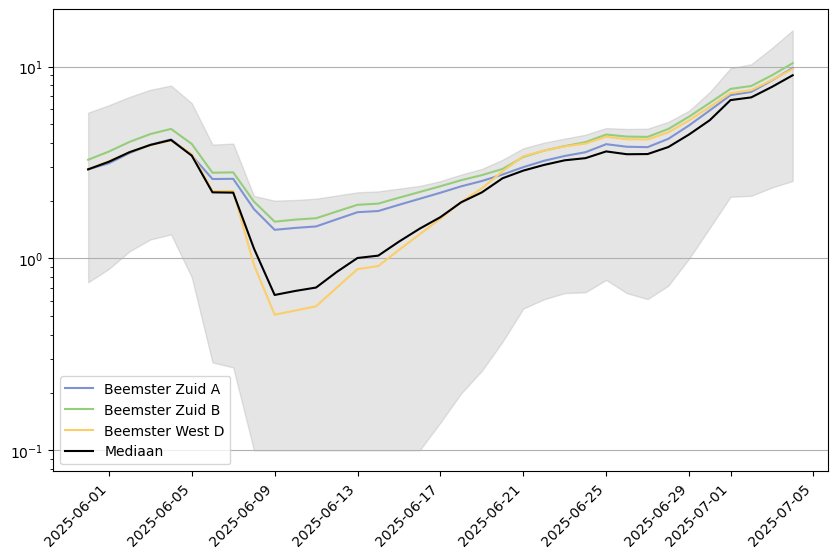

In [62]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 6))
df_gwdi_dynamic["datetime"] = pd.to_datetime(
    df_gwdi_dynamic["datetime"], unit="ms", utc=True
)
df_gwdi_agg = df_gwdi_dynamic.groupby("datetime")["value"].agg(["min", "median", "max"])
ax.fill_between(
    df_gwdi_agg.index,
    df_gwdi_agg["min"],
    df_gwdi_agg["max"],
    alpha=0.2,
    color="grey",
)

df_zuid_a = df_gwdi_dynamic.query("peilbuisid==@index_zuid_a")
ax.plot(
    df_zuid_a["datetime"], df_zuid_a["value"], color="#7d93d3", label="Beemster Zuid A"
)

df_zuid_b = df_gwdi_dynamic.query("peilbuisid==@index_zuid_b")
ax.plot(
    df_zuid_b["datetime"], df_zuid_b["value"], color="#95cd7a", label="Beemster Zuid B"
)

df_west = df_gwdi_dynamic.query("peilbuisid==@index_west")
ax.plot(df_west["datetime"], df_west["value"], color="#fbce69", label="Beemster West D")

ax.plot(df_gwdi_agg.index, df_gwdi_agg["median"], color="k", label="Mediaan")

ax.set_yscale("log")
ax.grid(True, axis="y")
# ax.set_ylim([0.1, 150])
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha="right")
ax.legend()